In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the data

data = pd.read_csv('../../../data/data_reduced_175_standard.csv')


display(data.columns)
data_id = data['apogee_id']

data_target = data[['class_spectral',
                    'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                    'class_lum_bins_jhk']]

# Suppression des colonnes non souhaitées
data = data.drop(columns=[
                          'apogee_id', 'class_spectral',
                          'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
                          'class_lum_bins_jhk', 'M_H', 'VMICRO', 'VMACRO',])

print(data.columns)
# Convert to float32
data = data.astype('float32').reset_index(drop=True)
print("Final Data Shape :", data.shape)


Index(['apogee_id', 'M_H', 'VMICRO', 'VMACRO', 'C_FE', 'CI_FE', 'N_FE', 'O_FE',
       'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 'TI_FE',
       'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H', 'class_spectral',
       'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg',
       'class_lum_bins_jhk'],
      dtype='object')

Index(['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE',
       'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE',
       'FE_H'],
      dtype='object')
Final Data Shape : (175809, 17)


In [4]:
217

217

In [5]:
# Convert to PyTorch tensors
full_data_tensor = torch.tensor(data.values, dtype=torch.float32)


In [6]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [21]:
# Split the data into training and validation sets (90/10 here)

# Set the seed for reproducibility
num_samples = len(full_data_tensor)
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size

# Split the data
train_data, val_data = torch.utils.data.random_split(
    full_data_tensor, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# Create the datasets
train_dataset = AutoencoderDataset(train_data.dataset[train_data.indices])
val_dataset = AutoencoderDataset(val_data.dataset[val_data.indices])

# Create the dataloaders
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)




In [22]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=20, latent_dim=2):
        super(Autoencoder, self).__init__()

        # Encoder : 20 -> 32 -> 64 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),                # BatchNorm should improve training
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, latent_dim)          # No activation after 2D layer latent space
        )

        # Decoder : 2 -> 64 -> 32 -> 20
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, input_dim)           # Output 20D vector
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device :", device)

model = Autoencoder(input_dim=17, latent_dim=2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device : cuda


In [24]:
num_epochs = 200
patience = 10             # Nb epochs to wait before early stopping
best_val_loss = float('inf')
epochs_no_improve = 0

In [25]:
# Define noise factor
noise_factor = 0.1

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # add noise
        noisy_X_batch = X_batch + noise_factor * torch.randn_like(X_batch)


        optimizer.zero_grad()
        outputs = model(noisy_X_batch)
        loss = criterion(outputs, X_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    # Calculate the average loss over all of the batches
    train_loss /= len(train_loader.dataset)

    # -- Validation --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

    # Early Stopping simple
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the model to disk
        torch.save(model.state_dict(), "best_autoencoder.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stop !")
            break

Epoch [1/200]  Train Loss: 0.639295  |  Val Loss: 0.426819
Epoch [2/200]  Train Loss: 0.399043  |  Val Loss: 0.383554
Epoch [3/200]  Train Loss: 0.375448  |  Val Loss: 0.369138
Epoch [4/200]  Train Loss: 0.363770  |  Val Loss: 0.359568
Epoch [5/200]  Train Loss: 0.355406  |  Val Loss: 0.352895
Epoch [6/200]  Train Loss: 0.348729  |  Val Loss: 0.345870
Epoch [7/200]  Train Loss: 0.343669  |  Val Loss: 0.341591
Epoch [8/200]  Train Loss: 0.339148  |  Val Loss: 0.337212
Epoch [9/200]  Train Loss: 0.335390  |  Val Loss: 0.333169
Epoch [10/200]  Train Loss: 0.331412  |  Val Loss: 0.329923
Epoch [11/200]  Train Loss: 0.328081  |  Val Loss: 0.326480
Epoch [12/200]  Train Loss: 0.325123  |  Val Loss: 0.323281
Epoch [13/200]  Train Loss: 0.322825  |  Val Loss: 0.320209
Epoch [14/200]  Train Loss: 0.320643  |  Val Loss: 0.318428
Epoch [15/200]  Train Loss: 0.318038  |  Val Loss: 0.319858
Epoch [16/200]  Train Loss: 0.316339  |  Val Loss: 0.316286
Epoch [17/200]  Train Loss: 0.315208  |  Val Loss

In [26]:
model.load_state_dict(torch.load("best_autoencoder.pth"))
model.eval()

with torch.no_grad():
    # Re encode the full data
    full_data_gpu = full_data_tensor.to(device)
    latent_2d = model.encoder(full_data_gpu).cpu().numpy()

print("Lattend space shape :", latent_2d.shape)  # Devrait être (175809, 2)
print("Embedding sample:\n", latent_2d[:5])

Lattend space shape : (175809, 2)
Embedding sample:
 [[-0.16671294  0.06584802]
 [-0.33898988  0.06156742]
 [-0.24616542  0.00612688]
 [-0.24169487  0.01468255]
 [-0.2787558  -0.03205872]]


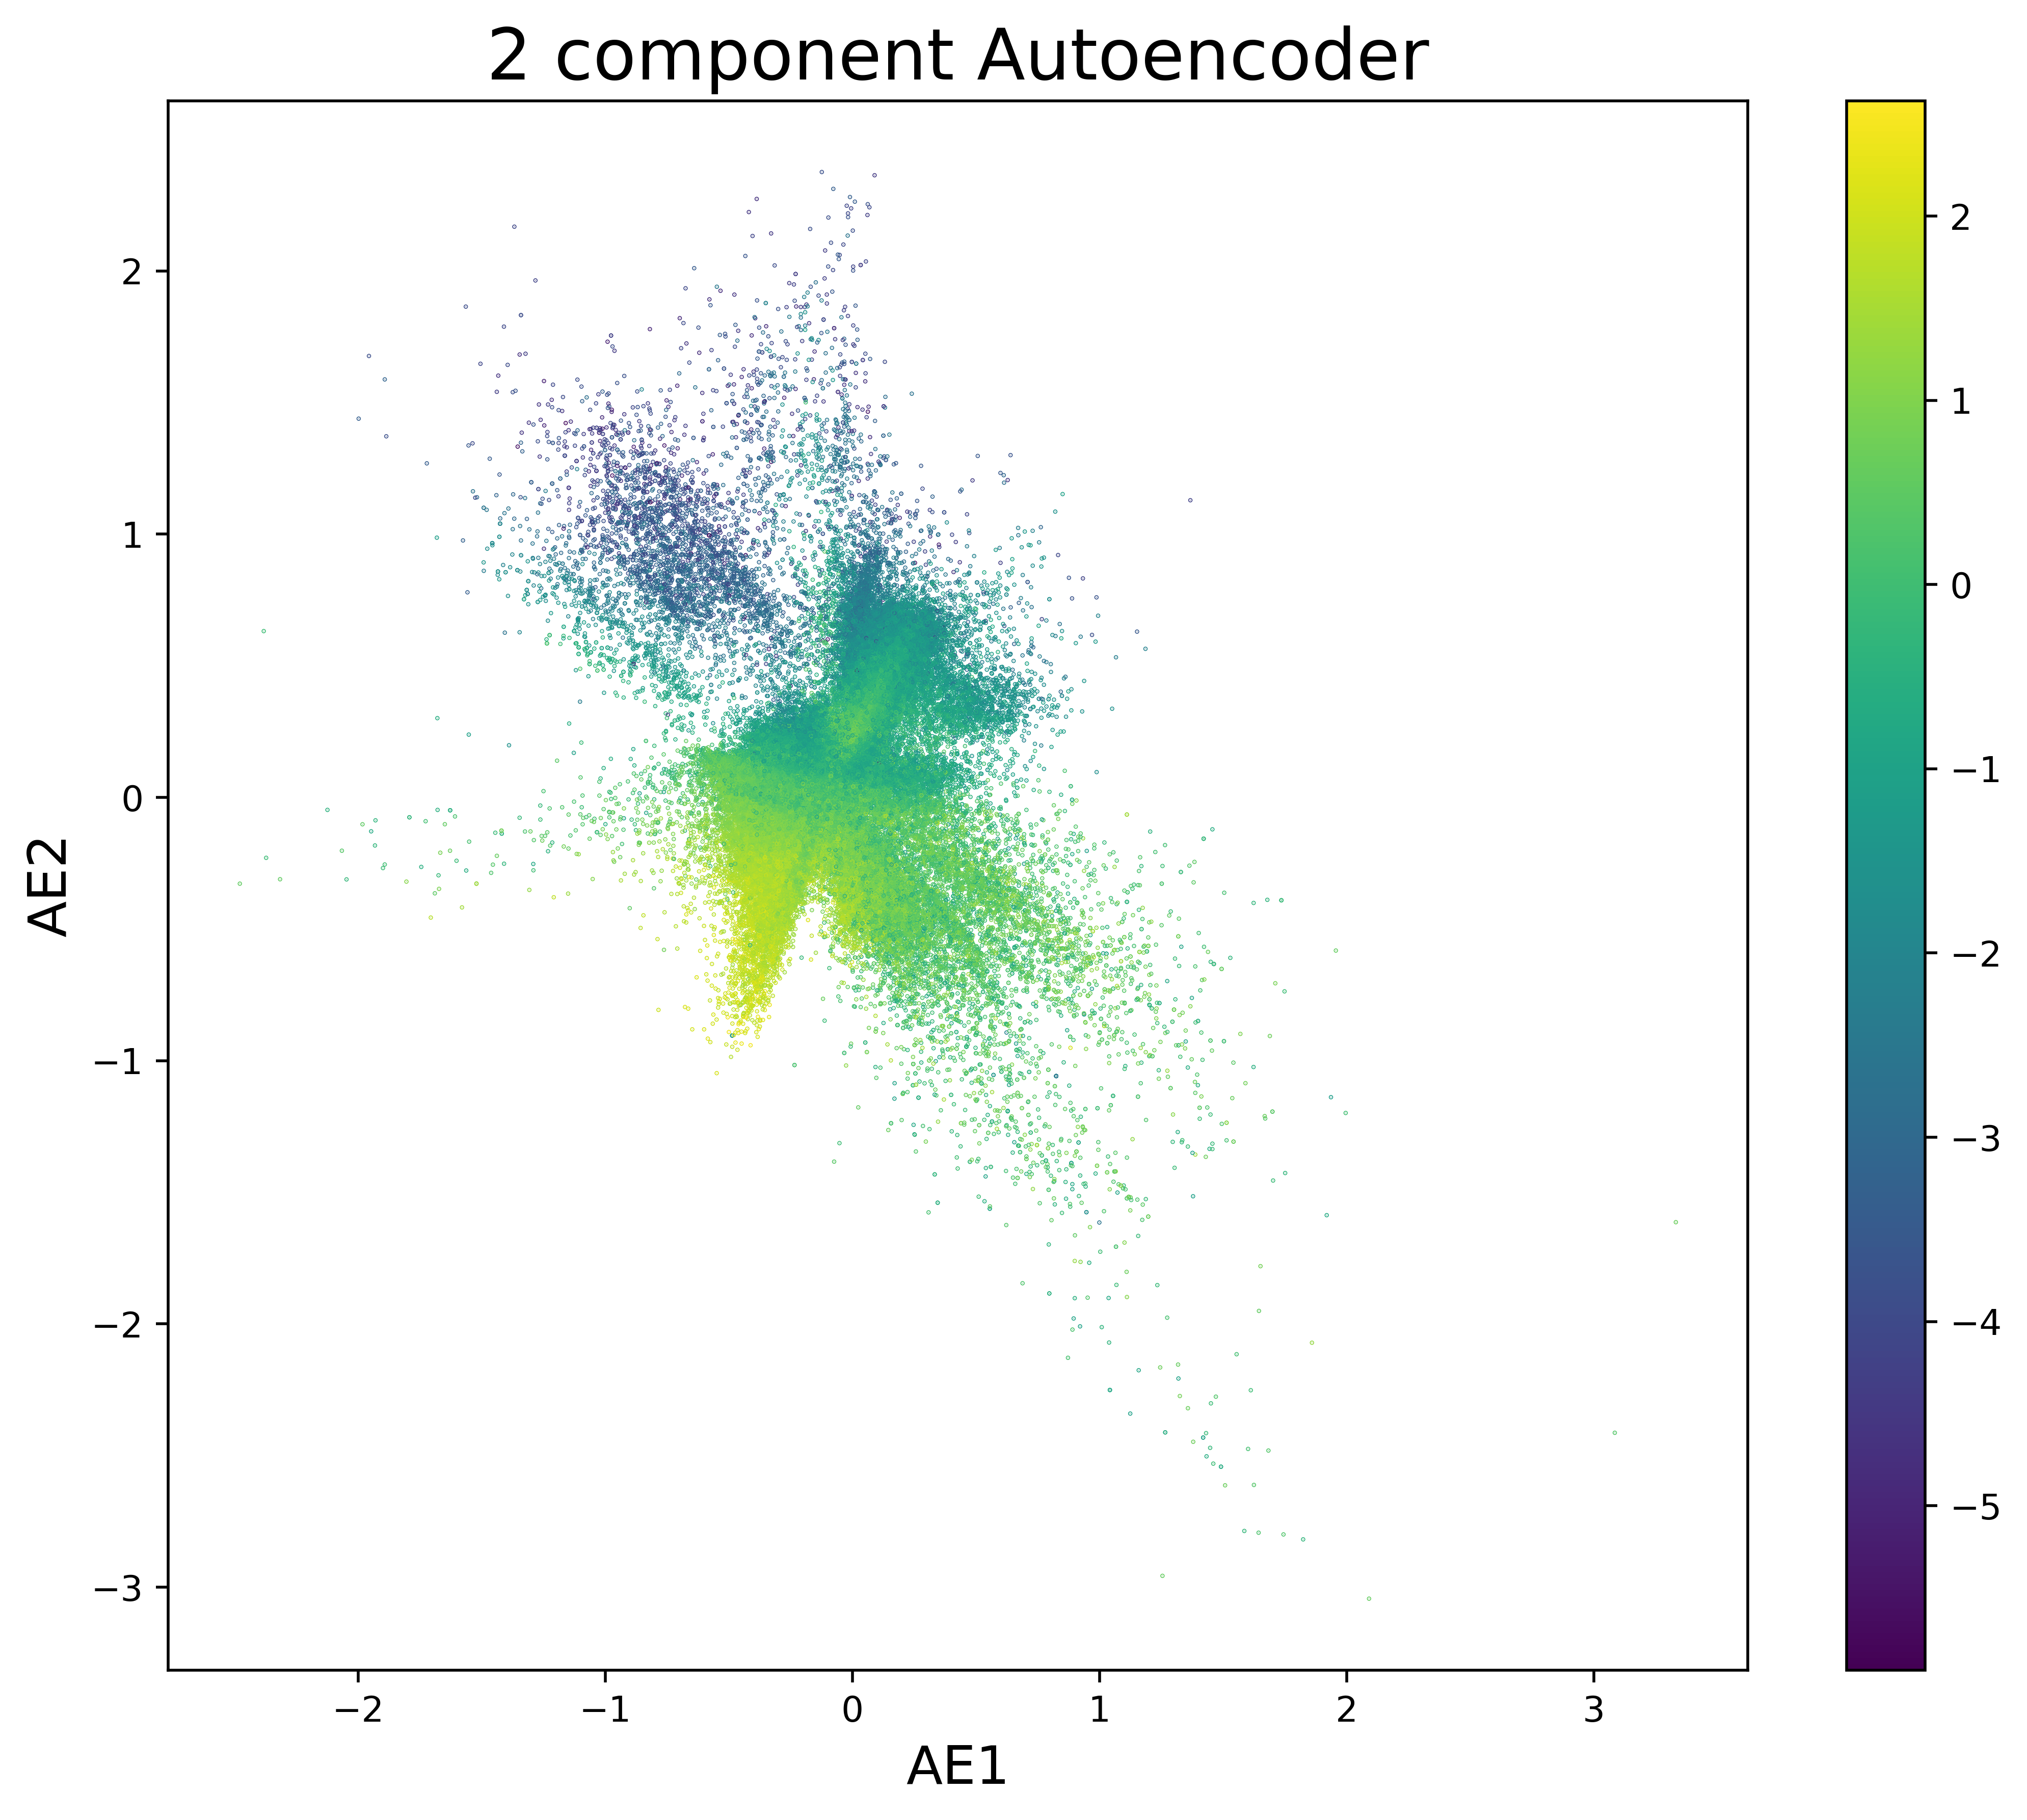

In [27]:
# Plot the Autoencoder result
fig = plt.figure(figsize=(10,8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('AE1', fontsize=15)
ax.set_ylabel('AE2', fontsize=15)
ax.set_title('2 component Autoencoder', fontsize=20)
# On utilise latent_2d[:,0] et latent_2d[:,1] pour les coordonnées X et Y respectivement
scatter = ax.scatter(latent_2d[:,0], latent_2d[:,1], c=data['FE_H'], cmap='viridis', s=0.05)
plt.colorbar(scatter)
plt.show()
